# GCAP3226 Week 4 — In-class exercise (5%)

**Individual.** Three tasks + submit (Commit & Push → Moodle GitHub URL).

| Task | Do this |
|------|---------|
| **1** | Percentage change by A&E triage; largest fall / rise; triage 4+5 combined |
| **2** | Grouped bar chart: H1 2025 vs H1 2026 attendances by triage (10 bars) + numbers / percentage change |
| **3** | Short write-up: one supporting point + one gap for the A&E claim |


## Setup

Run the next cell. Data: `w4_ae_triage_h1.csv` (**H1** 2025 vs **H1** 2026 attendances by triage).

**H1** = first half of the year (usually **1 January – 30 June**).

**AI:** `Cmd+I` / `Ctrl+I` on a code cell → implement the comment prompt → **Keep**. Interpretations in your own words.


In [2]:
# Setup — run first
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_FILE = "week4_ae_triage_h1.csv"
path = Path(DATA_FILE) if Path(DATA_FILE).is_file() else Path.cwd() / DATA_FILE
df = pd.read_csv(path)
print("Using:", path.resolve())
df


Using: /workspaces/GCAP3226_week4/week4_ae_triage_h1.csv


,triage,triage_name,attend_h1_2025,attend_h1_2026
0,1,Critical,13848,14541
1,2,Emergency,28554,29981
2,3,Urgent,400428,411994
3,4,Semi-urgent,489032,441974
4,5,Non-urgent,18448,14758


## Task 1 — Percentage change

**Purpose:** Measure how A&E attendances changed from H1 2025 to H1 2026 for each triage group, so you can see which groups rose or fell before judging the A&E claim in Task 3.

1. Add a column `pct_change` = `(attend_h1_2026 - attend_h1_2025) / attend_h1_2025 * 100`.
2. Show the table.
3. Print the triage with the **largest fall** and the **largest rise**.
4. Compute the percentage change for triage **4+5 combined** (sum attendances first, then apply the same formula).

Then, in the next cell, write **1–2 sentences** answering:
- Did triage **1–2** (Critical / Emergency) mainly **rise or fall**?
- Did triage **4–5** (Semi-urgent / Non-urgent) mainly **rise or fall**?
- In one short phrase: what does that pattern look like for the A&E claim (lower-urgency down; critical/emergency protected)?


In [3]:
# Task 1
#
# Input: df (triage, triage_name, attend_h1_2025, attend_h1_2026)
# Process: Calculate percentage changes, identify the largest fall/rise,
#          and calculate the combined change for triage 4+5
# Output: table + largest fall/rise + 4+5 combined percentage change
#
df["pct_change"] = (df["attend_h1_2026"] - df["attend_h1_2025"]) / df["attend_h1_2025"] * 100
display(df)

largest_fall = df.loc[df["pct_change"].idxmin()]
largest_rise = df.loc[df["pct_change"].idxmax()]
print(f"Largest fall: Triage {largest_fall['triage']} ({largest_fall['triage_name']}), {largest_fall['pct_change']:.2f}%")
print(f"Largest rise: Triage {largest_rise['triage']} ({largest_rise['triage_name']}), {largest_rise['pct_change']:.2f}%")

triage_45 = df.loc[df["triage"].isin([4, 5]), ["attend_h1_2025", "attend_h1_2026"]].sum()
combined_45_change = (triage_45["attend_h1_2026"] - triage_45["attend_h1_2025"]) / triage_45["attend_h1_2025"] * 100
print(f"Triage 4+5 combined: {combined_45_change:.2f}%")

,triage,triage_name,attend_h1_2025,attend_h1_2026,pct_change
0,1,Critical,13848,14541,5.004333
1,2,Emergency,28554,29981,4.997549
2,3,Urgent,400428,411994,2.888409
3,4,Semi-urgent,489032,441974,-9.622683
4,5,Non-urgent,18448,14758,-20.002168


Largest fall: Triage 5 (Non-urgent), -20.00%
Largest rise: Triage 1 (Critical), 5.00%
Triage 4+5 combined: -10.00%


In [4]:
# Task 1 note
task1_note = """
Triage 1–2 both rose by about 5%, while triage 4–5 fell, with their combined attendances down 10%. This pattern is consistent with lower-urgency attendances falling while critical/emergency care is protected, but the figures alone do not show that fee reform caused the changes.
"""
print(task1_note)


Triage 1–2 both rose by about 5%, while triage 4–5 fell, with their combined attendances down 10%. This pattern is consistent with lower-urgency attendances falling while critical/emergency care is protected, but the figures alone do not show that fee reform caused the changes.



## Task 2 — Visualization

**Purpose:** Turn the Task 1 table into a **grouped bar chart** that compares H1 2025 and H1 2026 attendances for each triage (5 groups, 2 bars each → 10 bars), and makes the **numbers** and **percentage change** easy to see.

In the next code cell, write your own IPO comment prompt, then use Inline Chat to implement it. Interpretations stay in your own words.


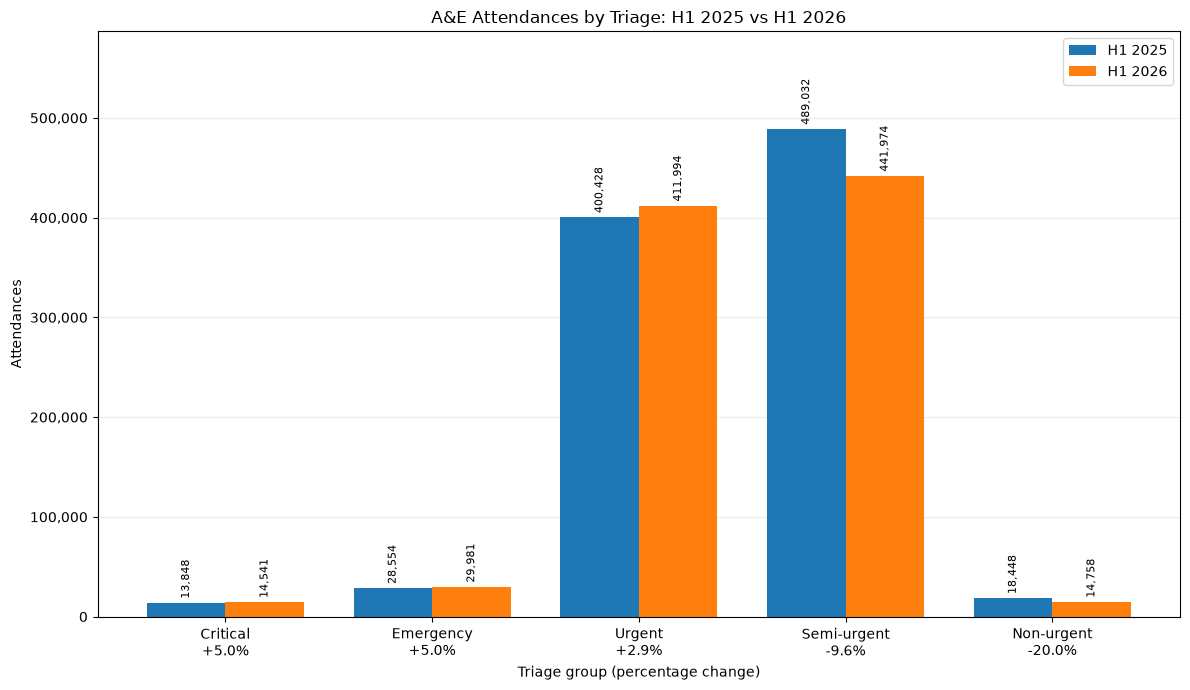

In [5]:
# Task 2 — IPO prompt
#
# Input:
#   Use df, which contains triage, triage_name, attend_h1_2025,
#   attend_h1_2026, and pct_change.
#
# Process:
#   Make a grouped bar chart with two bars for each triage group:
#   H1 2025 and H1 2026. Add the attendance number above each bar,
#   and show the percentage change for each triage group. Include a
#   title, axis labels, and a legend.
#
# Output:
#   A readable chart with five triage groups and ten bars in total,
#   comparing H1 2025 and H1 2026 attendances.

plot_df = df.sort_values("triage").copy()
positions = list(range(len(plot_df)))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(12, 7))
bars_2025 = ax.bar(
    [position - bar_width / 2 for position in positions],
    plot_df["attend_h1_2025"],
    width=bar_width,
    label="H1 2025",
    color="tab:blue",
)
bars_2026 = ax.bar(
    [position + bar_width / 2 for position in positions],
    plot_df["attend_h1_2026"],
    width=bar_width,
    label="H1 2026",
    color="tab:orange",
)

ax.bar_label(bars_2025, labels=[f"{value:,.0f}" for value in plot_df["attend_h1_2025"]], padding=3, rotation=90, fontsize=8)
ax.bar_label(bars_2026, labels=[f"{value:,.0f}" for value in plot_df["attend_h1_2026"]], padding=3, rotation=90, fontsize=8)
ax.set_xticks(positions)
ax.set_xticklabels([
    f"{name}\n{change:+.1f}%"
    for name, change in zip(plot_df["triage_name"], plot_df["pct_change"])
])
ax.set_ylim(0, plot_df[["attend_h1_2025", "attend_h1_2026"]].to_numpy().max() * 1.2)
ax.set_title("A&E Attendances by Triage: H1 2025 vs H1 2026")
ax.set_xlabel("Triage group (percentage change)")
ax.set_ylabel("Attendances")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:,.0f}"))
ax.legend()
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## Task 3 — Write-up

**Claim:** After fee reform, A&E improved — lower-urgency attendances fell; critical/emergency care stayed protected; urgent care became more efficient.

You may also cite: triage III within 30 min **81.4 → 88.5** (percentage); mean wait **23 → 20** min.

**3a** — Write **one supporting point** (cite a number) and **one gap** in the evidence.

**3b** — 2–4 sentences: how well is the claim supported by the published evidence (your table / chart, and any figures cited above)?


In [6]:
# Task 3
task3a = """
3a SUPPORT (1 point, cite a number):
Triage 4+5 combined attendances fell by 10.0%; meanwhile, triage III seen within 30 minutes rose from 81.4% to 88.5% and mean wait fell from 23 to 20 minutes.

3a GAP (1 point):
These before-and-after figures do not show that fee reform caused the changes, and increased critical/emergency attendance alone does not prove that care quality or outcomes were protected.
"""

task3b = """
3b:
The evidence partly supports the claim: triage 4+5 attendances fell by 10.0%, while triage 1–2 attendances rose by about 5%; the reported triage III 30-minute rate improved from 81.4% to 88.5%, and mean wait fell from 23 to 20 minutes. These patterns are consistent with fewer lower-urgency attendances and more efficient urgent care, but attendance counts alone cannot establish that critical/emergency care was protected. Without a comparison group or evidence that accounts for other changes, the figures cannot show that fee reform caused the improvements.
"""

print(task3a)
print("---")
print(task3b)


3a SUPPORT (1 point, cite a number):
Triage 4+5 combined attendances fell by 10.0%; meanwhile, triage III seen within 30 minutes rose from 81.4% to 88.5% and mean wait fell from 23 to 20 minutes.

3a GAP (1 point):
These before-and-after figures do not show that fee reform caused the changes, and increased critical/emergency attendance alone does not prove that care quality or outcomes were protected.

---

3b:
The evidence partly supports the claim: triage 4+5 attendances fell by 10.0%, while triage 1–2 attendances rose by about 5%; the reported triage III 30-minute rate improved from 81.4% to 88.5%, and mean wait fell from 23 to 20 minutes. These patterns are consistent with fewer lower-urgency attendances and more efficient urgent care, but attendance counts alone cannot establish that critical/emergency care was protected. Without a comparison group or evidence that accounts for other changes, the figures cannot show that fee reform caused the improvements.



## Submit

1. Save → Source Control → **Commit & Push**  
2. Moodle: paste your **GitHub URL**
